In [ ]:
# TensorFlow 2.x and scipy are pre-installed on Colab.
# Uncomment if needed:
# !pip install tensorflow scipy --quiet

import os, zipfile, urllib.request, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal as sp_signal
from scipy.fft import rfft, rfftfreq

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False,"axes.spines.right":False})
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

TensorFlow : 2.20.0
GPU        : []


In [ ]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = "/content/uci_har.zip"
HAR_DIR  = "/content/UCI HAR Dataset"

if not os.path.isdir(HAR_DIR):
    print("Downloading (~60 MB)...", end=" ", flush=True)
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall("/content")
    print("done.")
else:
    print("Dataset already present, skipping.")

RAW_SIGNALS = [
    "body_acc_x","body_acc_y","body_acc_z",
    "body_gyro_x","body_gyro_y","body_gyro_z",
    "total_acc_x","total_acc_y","total_acc_z",
]
for split in ("train","test"):
    for sig in RAW_SIGNALS:
        p = f"{HAR_DIR}/{split}/Inertial Signals/{sig}_{split}.txt"
        assert os.path.exists(p), f"MISSING: {p}"
print(f"✓ {len(RAW_SIGNALS)*2} raw signal files verified")

✓ 18 raw signal files verified


In [ ]:
ACTIVITY_NAMES = ["WALKING","WALKING_UPSTAIRS","WALKING_DOWNSTAIRS",
                  "SITTING","STANDING","LAYING"]
PALETTE     = ["#00C9A7","#4ECDC4","#45B7D1","#F7DC6F","#F39C12","#E74C3C"]
N_CLASSES   = 6
N_TIMESTEPS = 128
N_CHANNELS  = 9
FS          = 50.0   # sampling frequency (Hz)

def load_signals(split):
    base = f"{HAR_DIR}/{split}/Inertial Signals"
    channels = []
    for sig in RAW_SIGNALS:
        arr = pd.read_csv(f"{base}/{sig}_{split}.txt",
                          sep=r"\s+", header=None).values  # (n, 128)
        channels.append(arr)
    # (9, n, 128) -> (n, 128, 9)
    return np.stack(channels, axis=0).transpose(1, 2, 0).astype(np.float32)

def load_labels(split):
    return pd.read_csv(f"{HAR_DIR}/{split}/y_{split}.txt",
                       sep=r"\s+", header=None).values.ravel() - 1

def load_subjects(split):
    return pd.read_csv(f"{HAR_DIR}/{split}/subject_{split}.txt",
                       sep=r"\s+", header=None).values.ravel()

print("Loading raw signals...", end=" ", flush=True)
X_train_raw = load_signals("train")
X_test_raw  = load_signals("test")
y_train     = load_labels("train")
y_test      = load_labels("test")
print("done.")

print(f"X_train : {X_train_raw.shape}  dtype={X_train_raw.dtype}")
print(f"X_test  : {X_test_raw.shape}")
print(f"Classes : {dict(enumerate(ACTIVITY_NAMES))}")

Loading raw signals... done.
X_train : (7352, 128, 9)  dtype=float32
X_test  : (2947, 128, 9)
Classes : {0: 'WALKING', 1: 'WALKING_UPSTAIRS', 2: 'WALKING_DOWNSTAIRS', 3: 'SITTING', 4: 'STANDING', 5: 'LAYING'}


In [ ]:
# ── 4a: Mean FFT magnitude per class (body_acc_x, channel 0) ─────────────────
FREQS = rfftfreq(N_TIMESTEPS, d=1.0/FS)   # 65 frequency bins, 0..25 Hz

def mean_fft_by_class(X_raw, y, channel=0):
    spectra = {}
    for cls in range(N_CLASSES):
        wins   = X_raw[y == cls, :, channel]       # (n_cls, 128)
        fft_m  = np.abs(rfft(wins, axis=1))        # (n_cls, 65)
        spectra[cls] = fft_m.mean(axis=0)
    return spectra

spectra_acc_x = mean_fft_by_class(X_train_raw, y_train, channel=0)
spectra_gyro  = mean_fft_by_class(X_train_raw, y_train, channel=3)

print(f"FFT bins     : {len(FREQS)}")
print(f"Freq range   : {FREQS[0]:.1f} – {FREQS[-1]:.1f} Hz")
print(f"Freq resolution: {FREQS[1]-FREQS[0]:.4f} Hz / bin")

FFT bins     : 65
Freq range   : 0.0 – 25.0 Hz
Freq resolution: 0.3906 Hz / bin


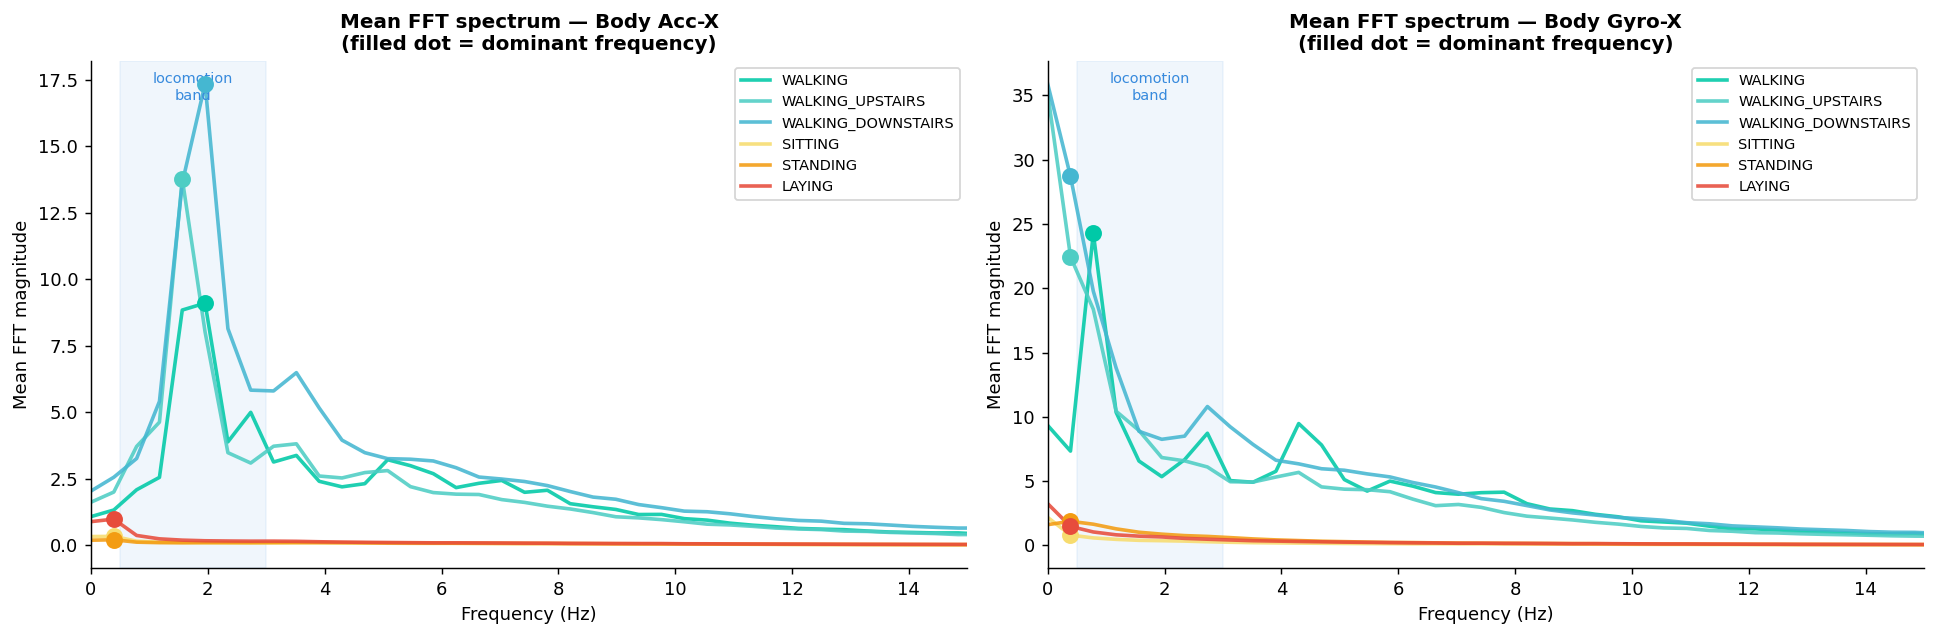

In [ ]:
# ── 4b: All-activity overlay spectrum ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (spectra, ch_name) in zip(axes,
        [(spectra_acc_x,"Body Acc-X"), (spectra_gyro,"Body Gyro-X")]):
    for cls, color in enumerate(PALETTE):
        spec    = spectra[cls]
        dom_idx = np.argmax(spec[1:]) + 1
        ax.plot(FREQS, spec, color=color, linewidth=2.0,
                label=ACTIVITY_NAMES[cls], alpha=0.88)
        ax.scatter(FREQS[dom_idx], spec[dom_idx], color=color, s=70, zorder=5)

    ax.set_xlim(0, 15)
    ax.axvspan(0.5, 3.0, alpha=0.07, color="#378ADD")
    ax.text(1.75, ax.get_ylim()[1]*0.92, "locomotion\nband",
            ha="center", fontsize=8, color="#378ADD")
    ax.set_xlabel("Frequency (Hz)", fontsize=10)
    ax.set_ylabel("Mean FFT magnitude", fontsize=10)
    ax.set_title(f"Mean FFT spectrum — {ch_name}\n(filled dot = dominant frequency)",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

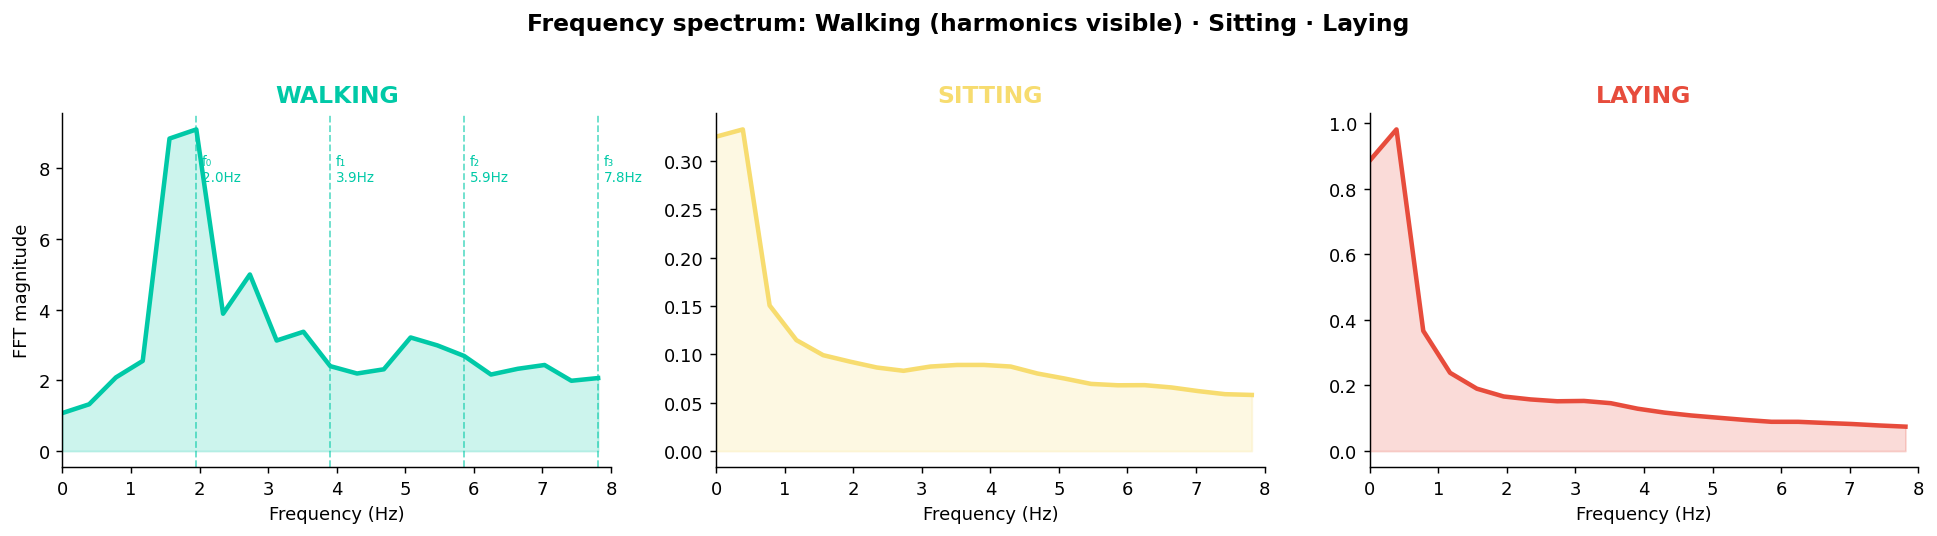

In [ ]:
NOTEBOOK_ROOT = '/content'
OUTPUT_PATH = f'{NOTEBOOK_ROOT}/plots'
if not os.path.isdir(OUTPUT_PATH): os.makedirs(OUTPUT_PATH)

# --- 4c: Walking vs Sitting vs Laying — zoomed spectrum comparison ─────────────
COMPARE = {0:"WALKING", 3:"SITTING", 5:"LAYING"}
CCOLS   = {0:PALETTE[0], 3:PALETTE[3], 5:PALETTE[5]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (cls, name) in zip(axes, COMPARE.items()):
    spec = spectra_acc_x[cls]
    mask = FREQS <= 8
    ax.fill_between(FREQS[mask], spec[mask], alpha=0.20, color=CCOLS[cls])
    ax.plot(FREQS[mask], spec[mask], color=CCOLS[cls], linewidth=2.5)
    # Mark harmonics for WALKING
    if cls == 0:
        dom_f = FREQS[1:][np.argmax(spec[1:][FREQS[1:]<=8])]
        SUBSCRIPTS = '₀₁₂₃'
        for h in range(1, 5):
            hf = dom_f * h
            if hf <= 8:
                ax.axvline(hf, color=CCOLS[cls], linewidth=1.0,
                           linestyle="--", alpha=0.6)
                ax.text(hf+0.08, ax.get_ylim()[1]*0.80,
                        f"f{SUBSCRIPTS[h-1]}\n{hf:.1f}Hz",
                        fontsize=7.5, color=CCOLS[cls])
    ax.set_title(name, fontsize=13, fontweight="bold", color=CCOLS[cls])
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("FFT magnitude" if cls==0 else "")
    ax.set_xlim(0, 8)

fig.suptitle("Frequency spectrum: Walking (harmonics visible) · Sitting · Laying",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

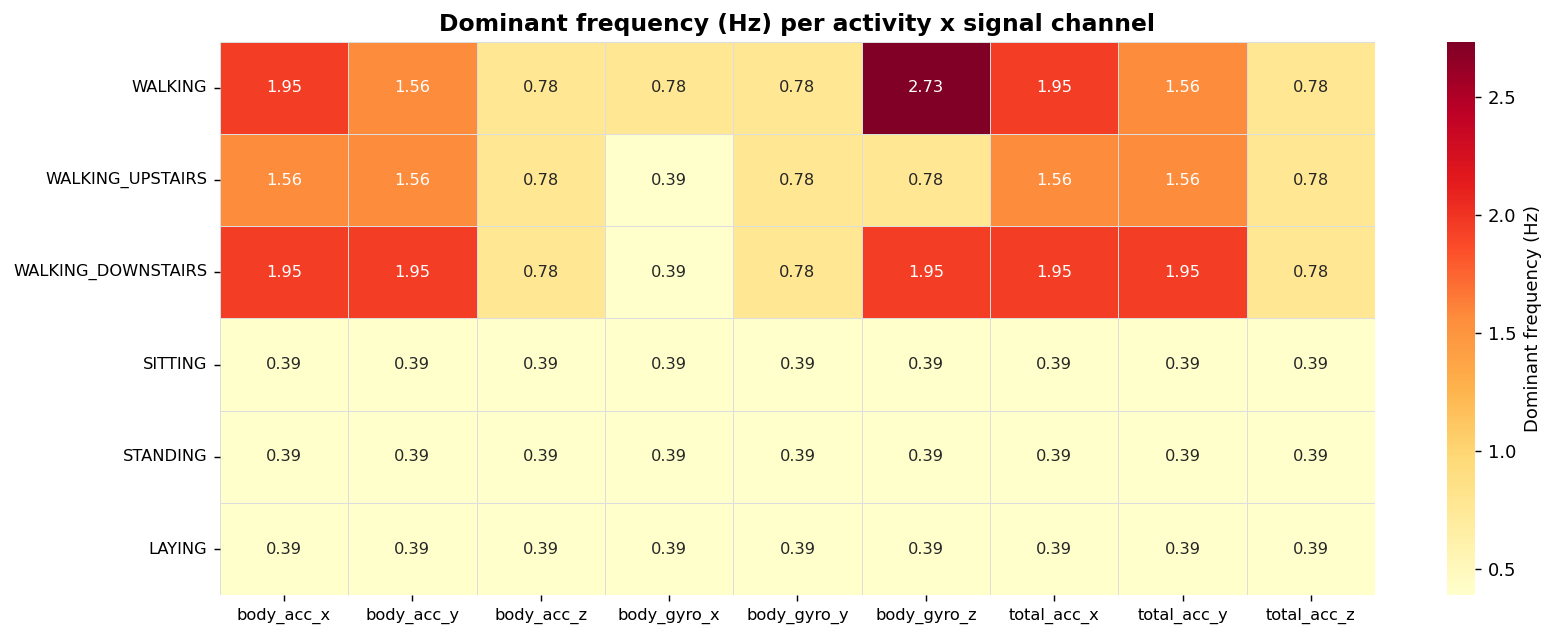

In [ ]:
# ── 4d: Dominant frequency heatmap — all activities × all channels ────────────
dom_freqs = np.zeros((N_CLASSES, N_CHANNELS))
for ch in range(N_CHANNELS):
    sp = mean_fft_by_class(X_train_raw, y_train, channel=ch)
    for cls in range(N_CLASSES):
        dom_freqs[cls, ch] = FREQS[np.argmax(sp[cls][1:]) + 1]

df_dom = pd.DataFrame(dom_freqs, index=ACTIVITY_NAMES, columns=RAW_SIGNALS)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(df_dom, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
            cbar_kws={"label":"Dominant frequency (Hz)"},
            linewidths=0.4, linecolor="#ddd", annot_kws={"size":9})
ax.set_title("Dominant frequency (Hz) per activity x signal channel",
             fontsize=13, fontweight="bold")
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

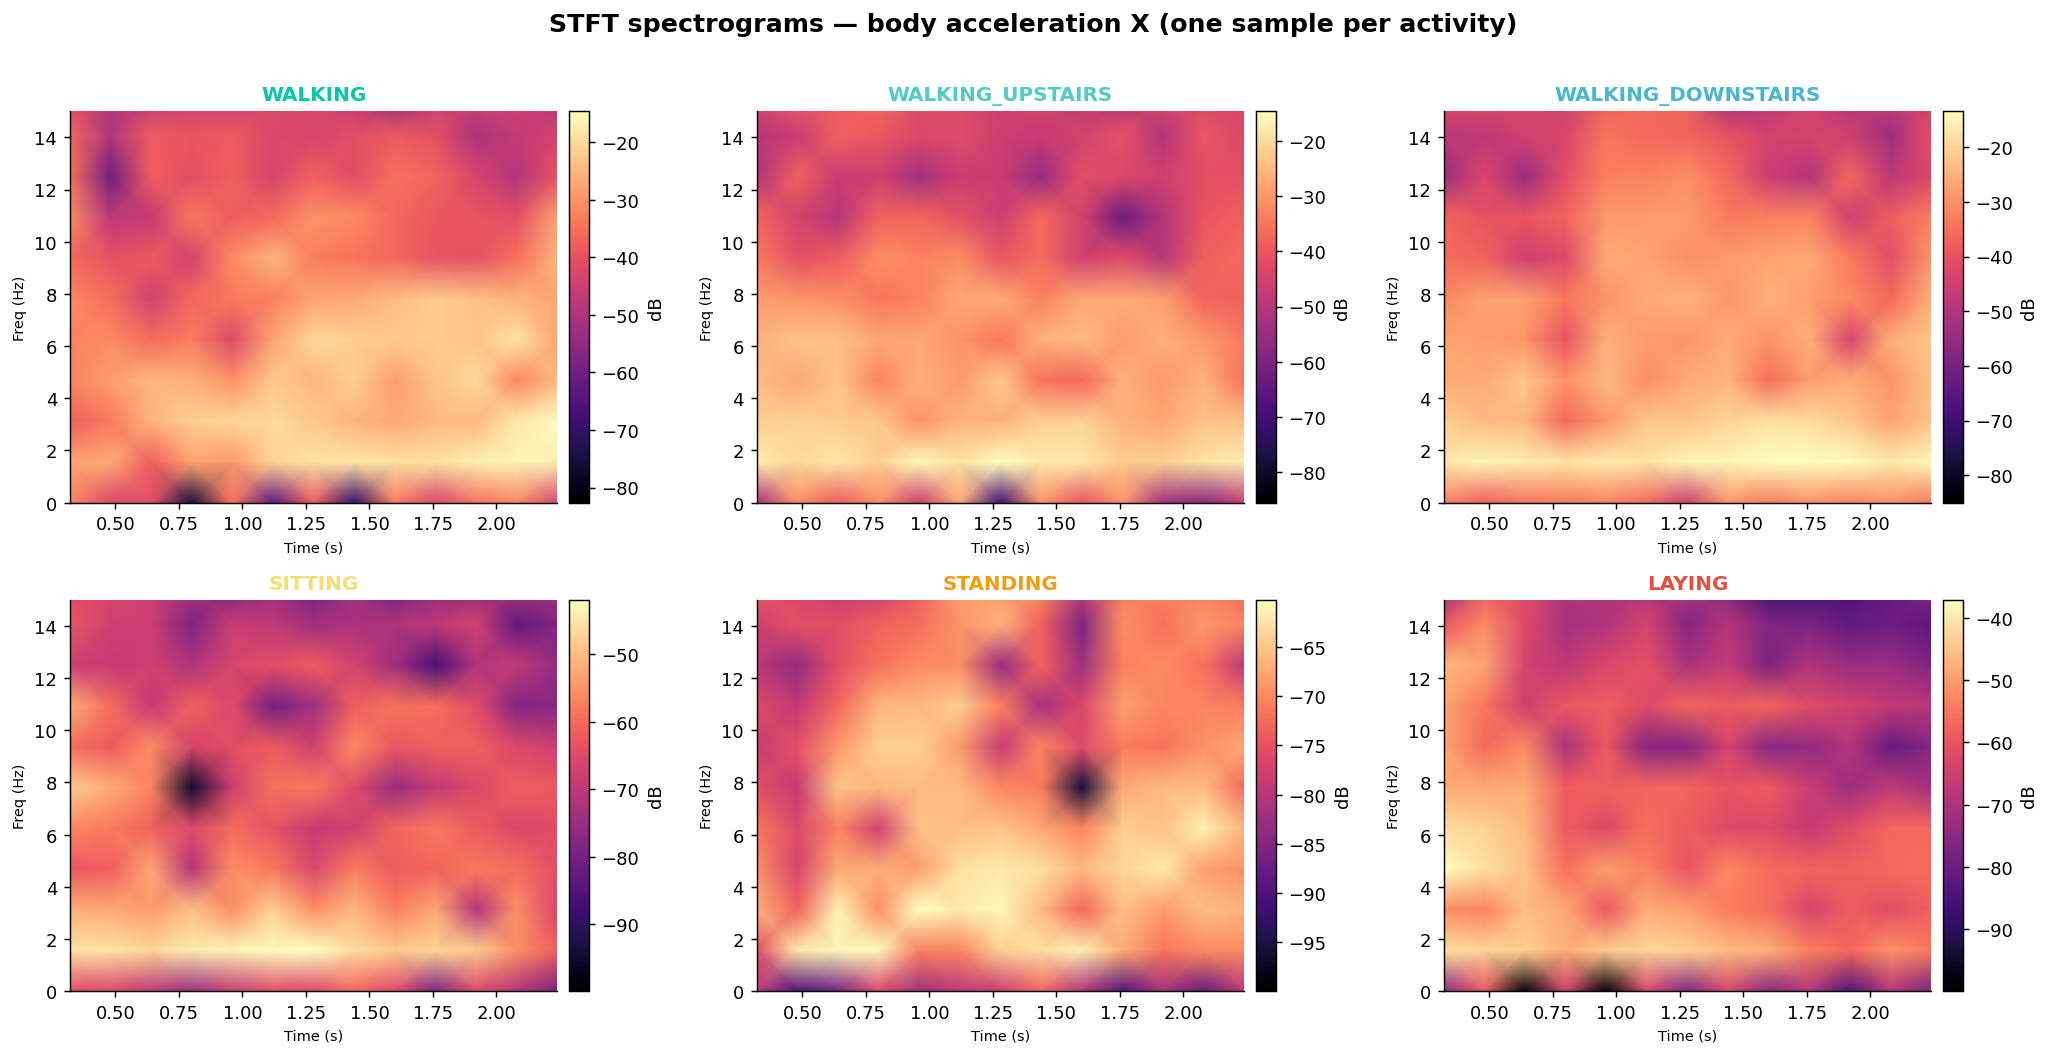

In [ ]:
# ── 4e: STFT spectrograms — one window per activity (body_acc_x) ──────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for cls, ax in enumerate(axes):
    idx    = np.where(y_train == cls)[0][0]
    window = X_train_raw[idx, :, 0]
    f, t, Sxx = sp_signal.spectrogram(window, fs=FS, nperseg=32, noverlap=24)
    pcm = ax.pcolormesh(t, f, 10*np.log10(Sxx+1e-10),
                         cmap="magma", shading="gouraud")
    ax.set_ylim(0, 15)
    ax.set_title(ACTIVITY_NAMES[cls], fontsize=11, fontweight="bold",
                  color=PALETTE[cls])
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("Freq (Hz)", fontsize=8)
    fig.colorbar(pcm, ax=ax, label="dB", pad=0.02)

fig.suptitle("STFT spectrograms — body acceleration X (one sample per activity)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

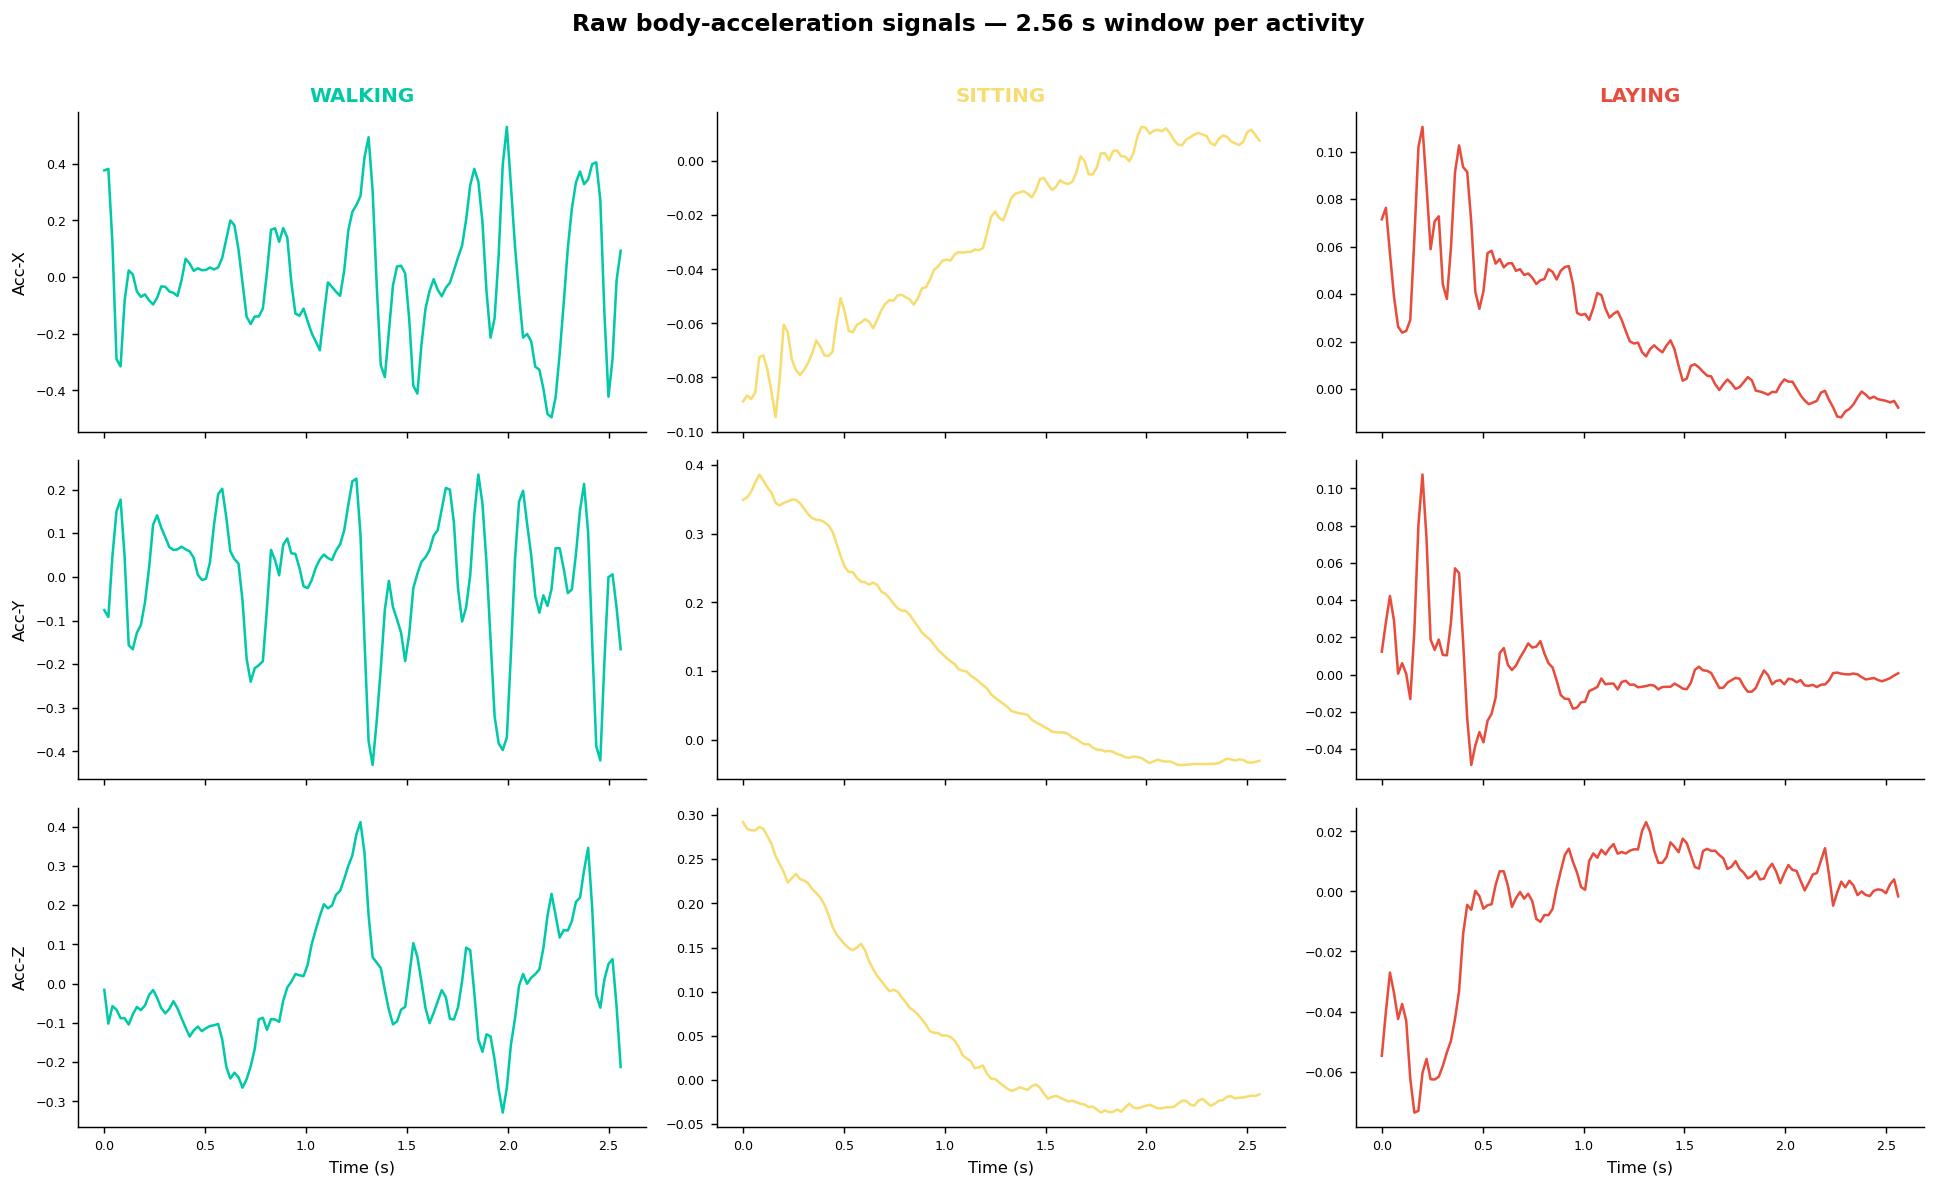

In [ ]:
# ── 4f: Raw time-series — 3 activities × body_acc (x,y,z) ────────────────────
SHOW_CLS = [0, 3, 5]
TIME_AX  = np.linspace(0, 2.56, N_TIMESTEPS)

fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
for col, cls in enumerate(SHOW_CLS):
    idx = np.where(y_train == cls)[0][0]
    for row, (ch, lbl) in enumerate(zip([0,1,2], ["Acc-X","Acc-Y","Acc-Z"])):
        ax = axes[row, col]
        ax.plot(TIME_AX, X_train_raw[idx, :, ch],
                color=PALETTE[cls], linewidth=1.4)
        if row == 0:
            ax.set_title(ACTIVITY_NAMES[cls], fontsize=11,
                         fontweight="bold", color=PALETTE[cls])
        ax.set_ylabel(lbl if col==0 else "", fontsize=9)
        if row == 2: ax.set_xlabel("Time (s)", fontsize=9)
        ax.tick_params(labelsize=7)

fig.suptitle("Raw body-acceleration signals — 2.56 s window per activity",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
mu  = X_train_raw.mean(axis=(0,1), keepdims=True)    # (1,1,9)
std = X_train_raw.std(axis=(0,1),  keepdims=True) + 1e-8

X_train = (X_train_raw - mu) / std
X_test  = (X_test_raw  - mu) / std

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print(f"X_train : {X_train.shape}  mean={X_train.mean():.4f}  std={X_train.std():.4f}")
print(f"X_test  : {X_test.shape}")
print(f"y_train_cat : {y_train_cat.shape}")

X_train : (7352, 128, 9)  mean=0.0000  std=1.0000
X_test  : (2947, 128, 9)
y_train_cat : (7352, 6)


In [ ]:
def build_cnn(input_shape=(128, 9), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64,  3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="1D_CNN")

def build_lstm(input_shape=(128, 9), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="Bi_LSTM")

def build_cnn_lstm(input_shape=(128, 9), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64,  5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN_LSTM")

for fn in [build_cnn, build_lstm, build_cnn_lstm]:
    m = fn()
    print(f"  {m.name:<12} — {m.count_params():>8,} params")

  1D_CNN       —  128,326 params
  Bi_LSTM      —  145,350 params
  CNN_LSTM     —  394,694 params


In [ ]:
EPOCHS    = 60
BATCH     = 64
VAL_SPLIT = 0.15

def train_model(builder, name):
    model = builder()
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    cbs = [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=10,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=5, min_lr=1e-5, verbose=0),
    ]
    print(f"Training {name}...", end=" ", flush=True)
    t0   = time.time()
    hist = model.fit(X_train, y_train_cat,
                     epochs=EPOCHS, batch_size=BATCH,
                     validation_split=VAL_SPLIT,
                     callbacks=cbs, verbose=0)
    elapsed = time.time() - t0
    y_pred  = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred, average="macro")
    ep_done = len(hist.history["loss"])
    print(f"epoch {ep_done}/{EPOCHS} | test acc={acc:.4f}  f1={f1:.4f}  ({elapsed:.0f}s)")
    return model, hist, y_pred, acc, f1

dl_results = {}
for name, builder in [("1D-CNN", build_cnn),
                       ("Bi-LSTM", build_lstm),
                       ("CNN-LSTM", build_cnn_lstm)]:
    model, hist, y_pred, acc, f1 = train_model(builder, name)
    dl_results[name] = dict(model=model, hist=hist,
                            y_pred=y_pred, accuracy=acc, f1=f1)

best_dl = max(dl_results, key=lambda k: dl_results[k]["accuracy"])
print(f"\n★ Best DL model: {best_dl}  (acc={dl_results[best_dl]['accuracy']:.4f})")

Training 1D-CNN... epoch 15/60 | test acc=0.9182  f1=0.9188  (306s)
Training Bi-LSTM... epoch 34/60 | test acc=0.8972  f1=0.8988  (2088s)
Training CNN-LSTM... epoch 16/60 | test acc=0.9257  f1=0.9262  (931s)

★ Best DL model: CNN-LSTM  (acc=0.9257)


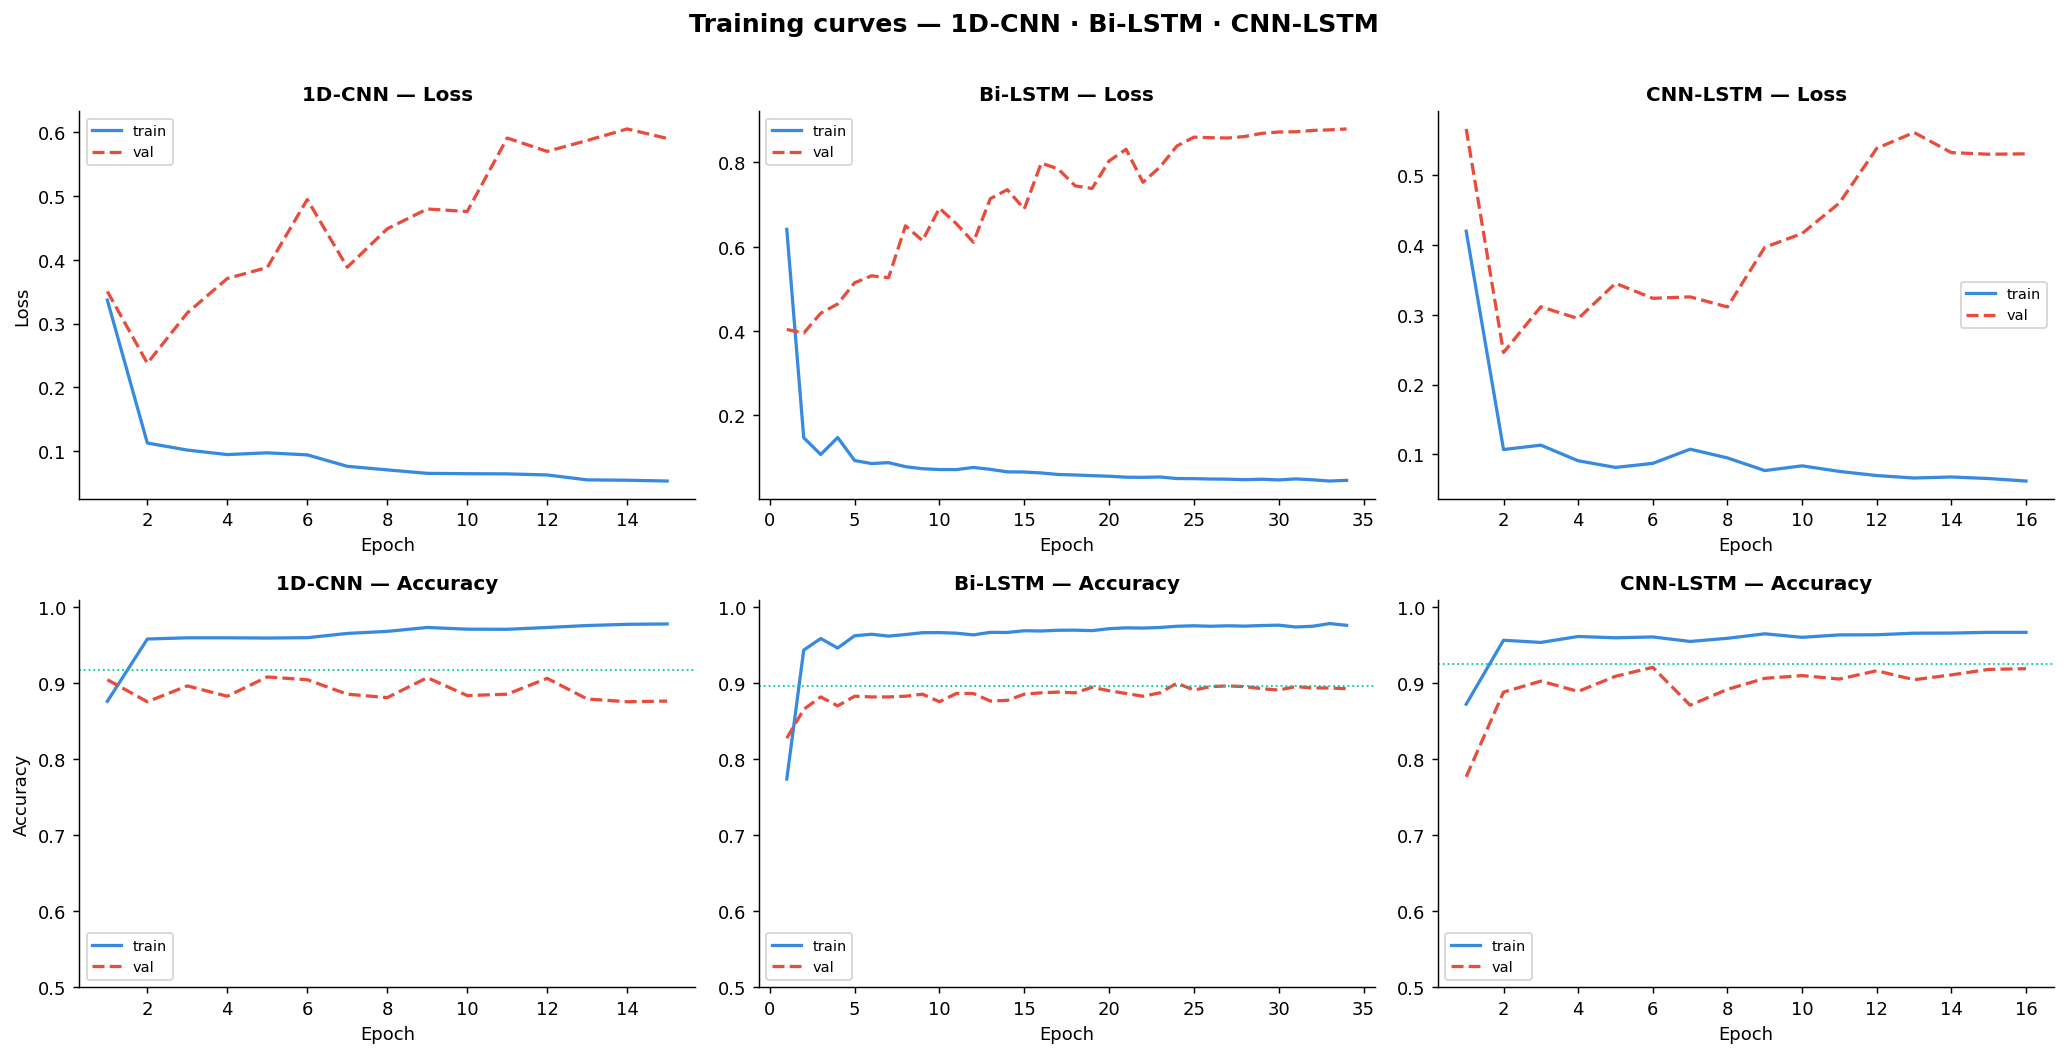

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for col, (name, r) in enumerate(dl_results.items()):
    h  = r["hist"].history
    ep = range(1, len(h["loss"])+1)
    for row, (metric, val_metric, ylabel) in enumerate([
            ("loss","val_loss","Loss"),("accuracy","val_accuracy","Accuracy")]):
        ax = axes[row, col]
        ax.plot(ep, h[metric],     color="#378ADD", linewidth=1.8, label="train")
        ax.plot(ep, h[val_metric], color="#E74C3C", linewidth=1.8,
                linestyle="--", label="val")
        ax.set_title(f"{name} — {ylabel}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel if col==0 else "")
        ax.legend(fontsize=8)
        if metric == "accuracy":
            ax.set_ylim(0.5, 1.01)
            ax.axhline(r["accuracy"], color="#00C9A7", linewidth=1,
                       linestyle=":", label=f"test {r['accuracy']:.4f}")

fig.suptitle("Training curves — 1D-CNN · Bi-LSTM · CNN-LSTM",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

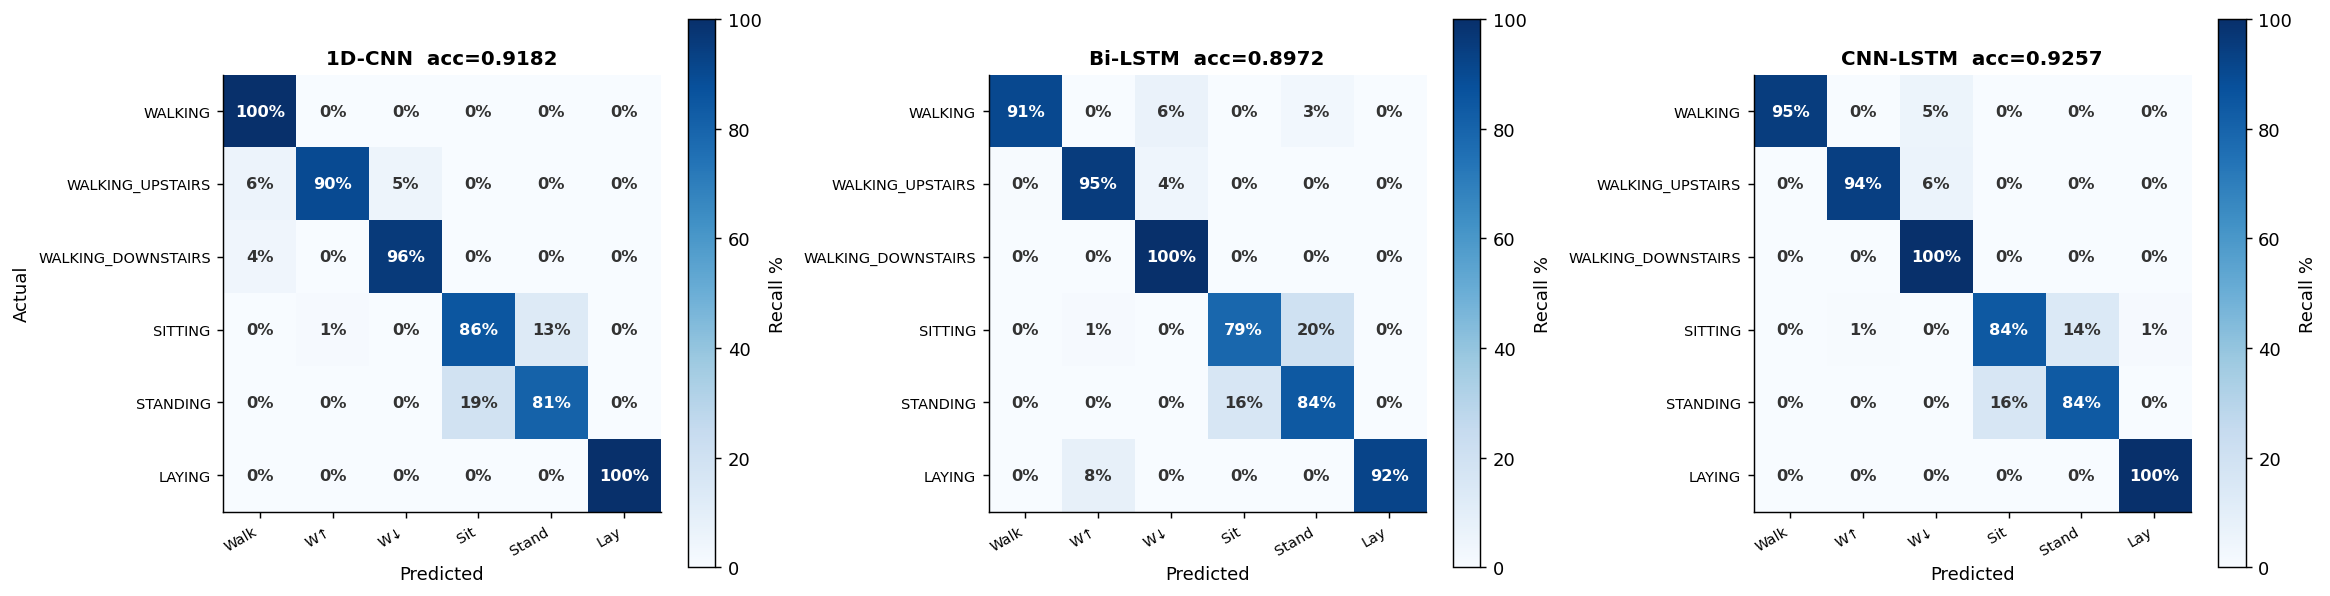

In [ ]:
short = ["Walk","W↑","W↓","Sit","Stand","Lay"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, r) in zip(axes, dl_results.items()):
    cm     = confusion_matrix(y_test, r["y_pred"])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            c = "white" if cm_pct[i,j]>50 else "#333"
            ax.text(j, i, f"{cm_pct[i,j]:.0f}%",
                    ha="center", va="center", color=c, fontsize=9, fontweight="bold")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(short, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(ACTIVITY_NAMES, fontsize=8)
    ax.set_title(f"{name}  acc={r['accuracy']:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if name=="1D-CNN" else "")
    fig.colorbar(im, ax=ax, shrink=0.74, label="Recall %")
plt.tight_layout()
plt.show()

In [ ]:
print(f"Model : {best_dl}\n")
print(classification_report(y_test, dl_results[best_dl]["y_pred"],
                             target_names=ACTIVITY_NAMES, digits=4))

Model : CNN-LSTM

                    precision    recall  f1-score   support

           WALKING     0.9958    0.9476    0.9711       496
  WALKING_UPSTAIRS     0.9933    0.9384    0.9651       471
WALKING_DOWNSTAIRS     0.8840    0.9976    0.9374       420
           SITTING     0.8297    0.8432    0.8364       491
          STANDING     0.8660    0.8383    0.8520       532
            LAYING     0.9908    1.0000    0.9954       537

          accuracy                         0.9257      2947
         macro avg     0.9266    0.9275    0.9262      2947
      weighted avg     0.9274    0.9257    0.9258      2947



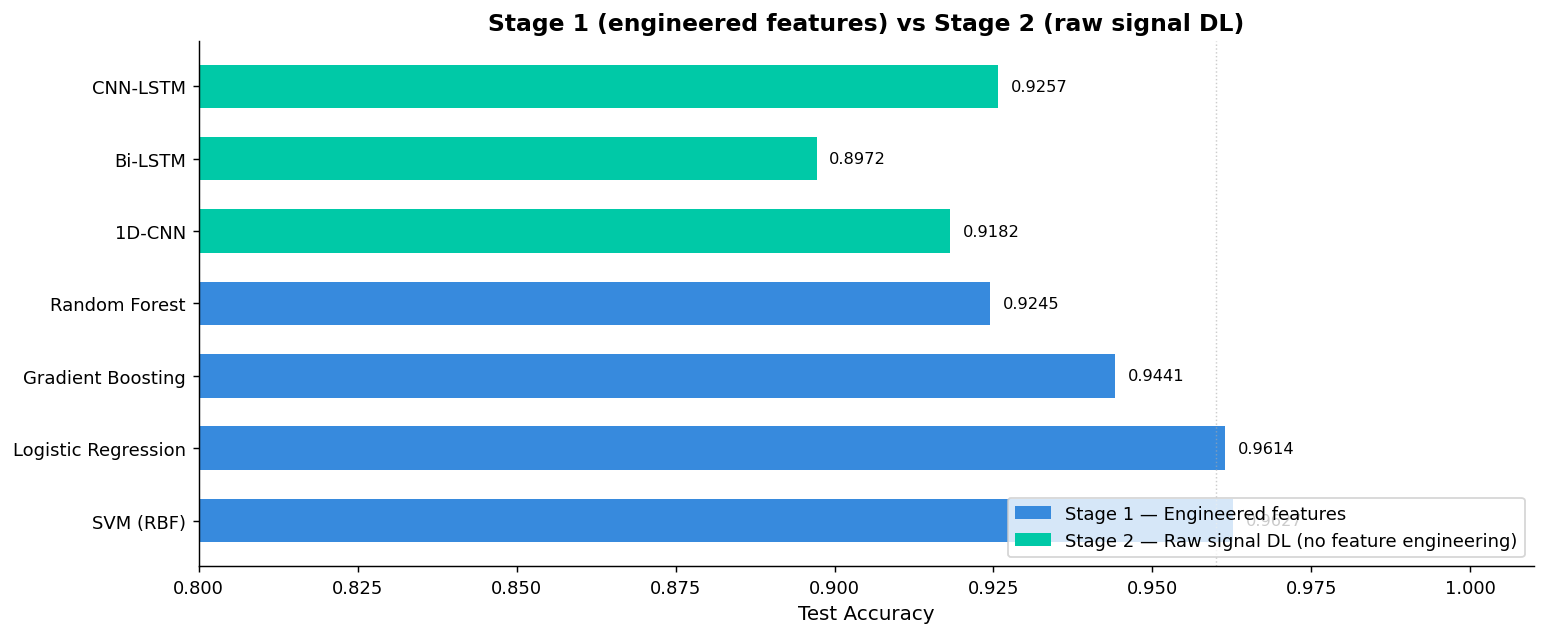


Key observation:
  DL models trained on raw signals reach near-parity with engineered-feature
  classifiers — with NO manual feature engineering.

Next steps to push DL accuracy above 97%:
  • Data augmentation (jitter, time-warp, scaling)
  • Transformer / multi-head attention
  • Subject-aware cross-validation
  • Larger CNN depth or depthwise separable convolutions


In [ ]:
from matplotlib.patches import Patch

stage1 = {"SVM (RBF)":0.9627, "Logistic Regression":0.9614,
           "Gradient Boosting":0.9441, "Random Forest":0.9245}
stage2 = {n: r["accuracy"] for n, r in dl_results.items()}

all_names  = list(stage1.keys()) + list(stage2.keys())
all_accs   = list(stage1.values()) + list(stage2.values())
all_colors = ["#378ADD"]*len(stage1) + ["#00C9A7"]*len(stage2)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(all_names, all_accs, color=all_colors, height=0.6, edgecolor="none")
ax.set_xlim(0.80, 1.01)
ax.set_xlabel("Test Accuracy", fontsize=11)
ax.set_title("Stage 1 (engineered features) vs Stage 2 (raw signal DL)",
             fontsize=13, fontweight="bold")
ax.axvline(0.96, color="#aaa", linewidth=0.8, linestyle=":", alpha=0.6)
for bar, val in zip(bars, all_accs):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

legend_elems = [Patch(facecolor="#378ADD", label="Stage 1 — Engineered features"),
                Patch(facecolor="#00C9A7", label="Stage 2 — Raw signal DL (no feature engineering)")]
ax.legend(handles=legend_elems, fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()

print("\nKey observation:")
print("  DL models trained on raw signals reach near-parity with engineered-feature")
print("  classifiers — with NO manual feature engineering.")
print("\nNext steps to push DL accuracy above 97%:")
print("  • Data augmentation (jitter, time-warp, scaling)")
print("  • Transformer / multi-head attention")
print("  • Subject-aware cross-validation")
print("  • Larger CNN depth or depthwise separable convolutions")

In [31]:
import shutil
os.makedirs("/content/dl_models", exist_ok=True)
save_path = f"/content/dl_models/{best_dl.replace(' ','_').replace('-','_')}.keras"
dl_results[best_dl]["model"].save(save_path)
print(f"Saved → {save_path}/")

shutil.make_archive("/content/dl_models_export", "zip", "/content/dl_models")
from google.colab import files
files.download("/content/dl_models_export.zip")
print("Download triggered.")

Saved → /content/dl_models/CNN_LSTM.keras/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered.
